Importing python tools and libraries

In [1]:
import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


mlflow.set_experiment('Credit_Card_Fraud_Detection')


<Experiment: artifact_location='file:///D:/AI%20internship/mlruns/874712242739371563', creation_time=1758685200651, experiment_id='874712242739371563', last_update_time=1758685200651, lifecycle_stage='active', name='Credit_Card_Fraud_Detection', tags={'mlflow.experimentKind': 'custom_model_development'}>

Importing Data Set

In [2]:
data=pd.read_csv("D:/AI internship/ai_intern/Credit_card/credit_card_transactions.csv")
data = data.sample(frac=0.3, random_state=42).reset_index(drop=True)
data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,...,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0
1,547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,...,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0,NaN
2,110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,...,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0
3,1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,...,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0,NaN
4,271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,...,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0


In [3]:
data.shape

(389002, 24)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389002 entries, 0 to 389001
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             389002 non-null  int64  
 1   trans_date_trans_time  389002 non-null  object 
 2   cc_num                 389002 non-null  int64  
 3   merchant               389002 non-null  object 
 4   category               389002 non-null  object 
 5   amt                    389002 non-null  float64
 6   first                  389002 non-null  object 
 7   last                   389002 non-null  object 
 8   gender                 389002 non-null  object 
 9   street                 389002 non-null  object 
 10  city                   389002 non-null  object 
 11  state                  389002 non-null  object 
 12  zip                    389002 non-null  int64  
 13  lat                    389002 non-null  float64
 14  long                   389002 non-nu

In [5]:
data.dtypes

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
merch_zipcode            float64
dtype: object

In [6]:
data.dtypes

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
merch_zipcode            float64
dtype: object

In [7]:
data.describe().T


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,389002.0,6.487708e+05,3.741498e+05,0.000000e+00,3.250735e+05,6.485655e+05,9.728752e+05,1.296673e+06
cc_num,389002.0,4.156365e+17,1.306453e+18,6.041621e+10,1.800365e+14,3.520550e+15,4.642255e+15,4.992346e+18
amt,389002.0,7.055259e+01,1.718061e+02,1.000000e+00,9.670000e+00,4.739000e+01,8.294000e+01,2.894890e+04
zip,389002.0,4.881083e+04,2.690642e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,389002.0,3.853553e+01,5.076142e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.189480e+01,6.669330e+01
long,389002.0,-9.023690e+01,1.376434e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,389002.0,8.811018e+04,3.015117e+05,2.300000e+01,7.410000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,389002.0,1.349259e+09,1.283494e+07,1.325376e+09,1.338769e+09,1.349263e+09,1.359408e+09,1.371817e+09
merch_lat,389002.0,3.853630e+01,5.109399e+00,1.902980e+01,3.473180e+01,3.936479e+01,4.195329e+01,6.751027e+01
merch_long,389002.0,-9.023648e+01,1.377708e+01,-1.666554e+02,-9.690709e+01,-8.744516e+01,-8.023326e+01,-6.695600e+01


In [8]:

data.is_fraud.value_counts()

is_fraud
0    386717
1      2285
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

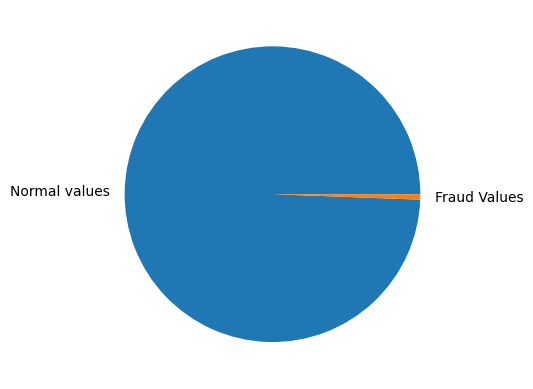

In [9]:
plt.pie(data.is_fraud.value_counts(),labels=["Normal values","Fraud Values"])
plt.show

Data Preprocessing

In [10]:
data.drop_duplicates()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,...,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0
1,547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,...,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0,NaN
2,110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,...,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0
3,1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,...,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0,NaN
4,271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,...,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388997,612347,2019-09-16 21:10:06,3596217206093829,"fraud_Labadie, Treutel and Bode",shopping_net,2.82,Sara,Ramirez,F,23843 Scott Island,...,-91.9534,888,Camera operator,1988-03-25,8c64aceafc029fee81a70ef48d5431a3,1347829806,40.393014,-91.088020,0,62321.0
388998,421133,2019-07-08 10:45:21,2356276337669917,fraud_Friesen-Stamm,gas_transport,65.09,Benjamin,Harris,M,0881 Lori Pines,...,-76.2842,5848,Paediatric nurse,1981-02-15,d31ec09e43ac74e673d0a02135c52139,1341744321,38.691606,-76.351589,0,21671.0
388999,695406,2019-10-23 22:59:49,2305336922781618,"fraud_Hyatt, Russel and Gleichner",health_fitness,22.57,Jeffrey,Rice,M,21447 Powell Circle,...,-92.6833,1132,Probation officer,1961-02-14,36ff67e6e3d92bf701c9ea5a63154562,1351033189,41.593444,-92.216461,0,52316.0
389000,1259079,2020-06-08 02:11:28,30561214688470,fraud_Torp-Labadie,gas_transport,63.91,Gina,Morrison,F,41851 Victor Drives Suite 219,...,-75.4645,166081,"Scientist, research (maths)",1998-10-01,1ff2bf0f8d6bd6eab11aeedc56b98277,1370657488,40.514858,-76.232734,0,19507.0


In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.dropna()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,...,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0
2,110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,...,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0
4,271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,...,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0
5,391181,2019-06-28 10:46:05,4855488158131690372,"fraud_Schuppe, Nolan and Hoeger",shopping_pos,129.80,Jeremy,Roberson,M,25887 Martin Inlet,...,-72.4847,970,Agricultural consultant,1993-09-29,2203dd06764180b6314dca2b21df2494,1340880365,44.272392,-72.743707,0,5660.0
6,962652,2020-01-23 09:09:59,30427035050508,fraud_Kuhic Inc,grocery_pos,111.10,John,Chandler,M,88325 Brandon Greens Apt. 477,...,-83.0796,673342,Broadcast presenter,1969-11-20,7b44d808a40f8ac414736be6a038e83c,1358932199,42.170491,-83.291412,0,48180.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388997,612347,2019-09-16 21:10:06,3596217206093829,"fraud_Labadie, Treutel and Bode",shopping_net,2.82,Sara,Ramirez,F,23843 Scott Island,...,-91.9534,888,Camera operator,1988-03-25,8c64aceafc029fee81a70ef48d5431a3,1347829806,40.393014,-91.088020,0,62321.0
388998,421133,2019-07-08 10:45:21,2356276337669917,fraud_Friesen-Stamm,gas_transport,65.09,Benjamin,Harris,M,0881 Lori Pines,...,-76.2842,5848,Paediatric nurse,1981-02-15,d31ec09e43ac74e673d0a02135c52139,1341744321,38.691606,-76.351589,0,21671.0
388999,695406,2019-10-23 22:59:49,2305336922781618,"fraud_Hyatt, Russel and Gleichner",health_fitness,22.57,Jeffrey,Rice,M,21447 Powell Circle,...,-92.6833,1132,Probation officer,1961-02-14,36ff67e6e3d92bf701c9ea5a63154562,1351033189,41.593444,-92.216461,0,52316.0
389000,1259079,2020-06-08 02:11:28,30561214688470,fraud_Torp-Labadie,gas_transport,63.91,Gina,Morrison,F,41851 Victor Drives Suite 219,...,-75.4645,166081,"Scientist, research (maths)",1998-10-01,1ff2bf0f8d6bd6eab11aeedc56b98277,1370657488,40.514858,-76.232734,0,19507.0


In [13]:
data.isnull()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
388998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
388999,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
389000,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
data.isnull().sum()

Unnamed: 0                   0
trans_date_trans_time        0
cc_num                       0
merchant                     0
category                     0
amt                          0
first                        0
last                         0
gender                       0
street                       0
city                         0
state                        0
zip                          0
lat                          0
long                         0
city_pop                     0
job                          0
dob                          0
trans_num                    0
unix_time                    0
merch_lat                    0
merch_long                   0
is_fraud                     0
merch_zipcode            58746
dtype: int64

In [15]:
data.nunique()

Unnamed: 0               389002
trans_date_trans_time    387004
cc_num                      979
merchant                    693
category                     14
amt                       33587
first                       351
last                        480
gender                        2
street                      979
city                        891
state                        51
zip                         967
lat                         965
long                        966
city_pop                    876
job                         492
dob                         964
trans_num                389002
unix_time                387004
merch_lat                384528
merch_long               387121
is_fraud                      2
merch_zipcode             27199
dtype: int64

 Drooping Columns

In [16]:
data=data.drop(columns=['Unnamed: 0', 'first', 'last', 'state', 'city', 'dob', 'merch_zipcode', 'zip', 'lat', 'long', 'city_pop','merch_zipcode'])


In [17]:
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,job,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,M,25454 Leonard Lake,Public relations account executive,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0
1,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,F,7177 Steven Forges,Retail merchandiser,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0
2,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,F,4879 Cristina Station,Systems developer,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0
3,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,M,841 Cheryl Centers Suite 115,Cytogeneticist,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0
4,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,F,8619 Lisa Manors Apt. 871,Product/process development scientist,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0


In [18]:
data.nunique()

trans_date_trans_time    387004
cc_num                      979
merchant                    693
category                     14
amt                       33587
gender                        2
street                      979
job                         492
trans_num                389002
unix_time                387004
merch_lat                384528
merch_long               387121
is_fraud                      2
dtype: int64

Binning amt

In [19]:
le=LabelEncoder()
bins=[0,25,50,100,200,500,1000, float("inf")]
labels=["very_low", "low", "medium", "high", "Very_high", "super_high", "extreme_high"]
data["amt_bin"]=pd.cut(data["amt"], bins=bins, labels=labels)
data["amt_bin"] = le.fit_transform(data["amt_bin"].astype(str))

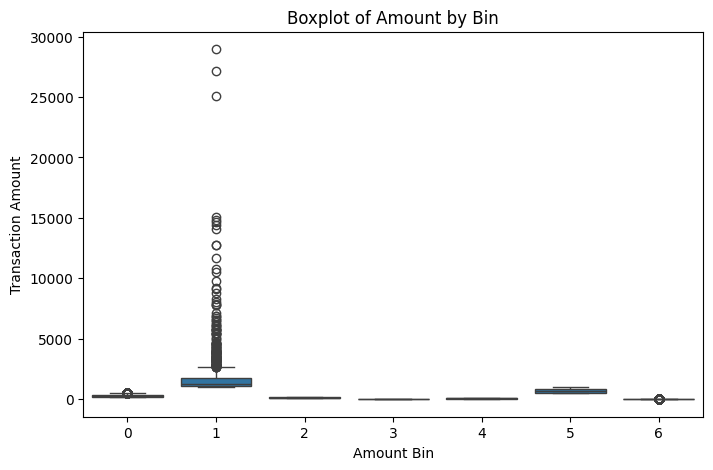

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x="amt_bin", y="amt", data=data, order=sorted(data["amt_bin"].unique()))
plt.title("Boxplot of Amount by Bin")
plt.xlabel("Amount Bin")
plt.ylabel("Transaction Amount")
plt.show()

Converting non-numerical data into numerical form

In [21]:
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])
data['trans_date'] = data['trans_date_trans_time'].dt.date
data['trans_time'] = data['trans_date_trans_time'].dt.time


In [22]:
data=data.drop(columns=['trans_date_trans_time','amt'])


In [23]:
encoder=LabelEncoder()
data['trans_date']=encoder.fit_transform(data['trans_date'])
data['trans_time']=encoder.fit_transform(data['trans_time'])
data['cc_num']=encoder.fit_transform(data['cc_num'])
data['merchant']=encoder.fit_transform(data['merchant'])
data['category']=encoder.fit_transform(data['category'])
data['gender']=encoder.fit_transform(data['gender'])
data['street']=encoder.fit_transform(data['street'])
data['trans_num']=encoder.fit_transform(data['trans_num'])
data['unix_time']=encoder.fit_transform(data['unix_time'])
data['merch_lat']=encoder.fit_transform(data['merch_lat'])
data['merch_long']=encoder.fit_transform(data['merch_long'])
data['job']=encoder.fit_transform(data['job'])






In [24]:
data.head()

,cc_num,merchant,category,gender,street,job,trans_num,unix_time,merch_lat,merch_long,is_fraud,amt_bin,trans_date,trans_time
0,33,629,9,1,249,377,388949,311810,231477,309225,0,2,432,53284
1,191,180,5,0,710,399,316907,163201,309896,3611,0,4,233,55652
2,732,429,12,0,490,443,206392,32661,233613,308784,0,6,62,5514
3,473,187,6,1,835,114,237354,383788,332637,332454,0,6,531,70913
4,819,92,2,0,853,357,39050,81078,255876,57296,0,4,133,20702


Training and Processing

In [25]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split

In [26]:
x = data.drop("is_fraud", axis=1)
y = data["is_fraud"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [27]:
scalar=StandardScaler()
X_train_scale = scalar.fit_transform(x_train)
X_test_scale = scalar.fit_transform(x_test)





In [28]:
smote=SMOTE(random_state=42)
x_train_resample, y_train_resample = smote.fit_resample(X_train_scale,y_train)

In [29]:
print("Resampled Class Distribution:", Counter(y_train_resample))

Resampled Class Distribution: Counter({0: 270710, 1: 270710})


DATA Modelling

Hyperparameter tunning

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1,2,4]
}

rf=RandomForestClassifier(class_weight="balanced", random_state=42)
grid = RandomizedSearchCV(
    rf, param_distributions=params, n_iter=5, cv=3, scoring="f1", n_jobs=-1, verbose=2)
grid.fit(x_train_resample, y_train_resample)
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}


Accuracy: 0.8749625110324676
F1 Score: 0.06891271056661562
              precision    recall  f1-score   support

           0       1.00      0.88      0.93    116007
           1       0.04      0.78      0.07       694

    accuracy                           0.87    116701
   macro avg       0.52      0.83      0.50    116701
weighted avg       0.99      0.87      0.93    116701

[[101569  14438]
 [   154    540]]


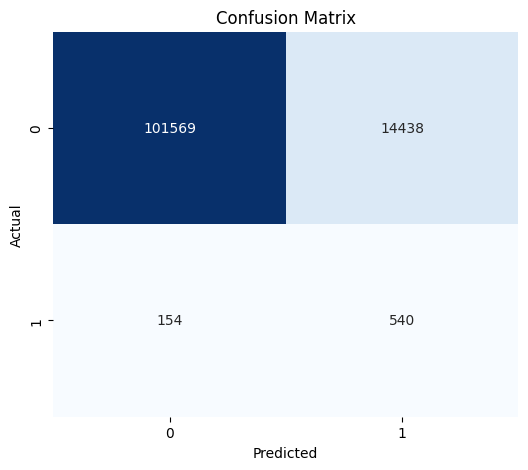

2025/10/10 06:00:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [31]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_pred = best_model.predict(X_test_scale)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

with mlflow.start_run():
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("Accuracy", accuracy_score(y_test, y_pred))
    mlflow.log_metric("F1 Score", f1_score(y_test, y_pred))
    mlflow.sklearn.log_model(best_model, name="RandomForestModel")
    

Feature Importance

In [32]:
print("BH")

BH


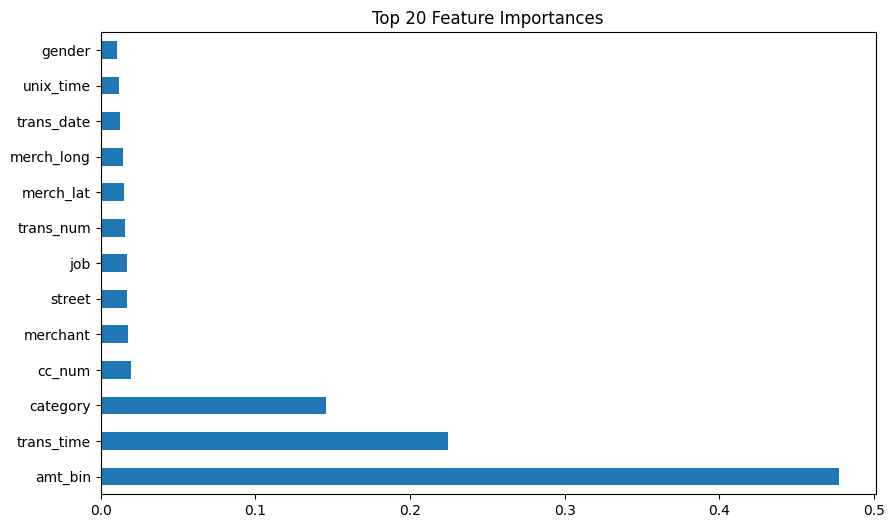

In [33]:
feat_imp = pd.Series(best_model.feature_importances_, index=x.columns)
feat_imp.nlargest(20).plot(kind="barh", figsize=(10,6))
plt.title("Top 20 Feature Importances")
plt.show()

SHAP VALUE

In [1]:
print("BI")


BI


In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

X_test_df = pd.DataFrame(X_test_scale, columns=x_test.columns)

explainer = shap.TreeExplainer(best_model, feature_perturbation="tree_path_dependent")

shap_values = explainer.shap_values(X_test_df, check_additivity=False)

if isinstance(shap_values, list):
    print(f"SHAP returned a list with {len(shap_values)} elements.")
    shap_to_plot = shap_values[1]  
else:
    shap_to_plot = shap_values

if shap_to_plot.shape[1] != X_test_df.shape[1]:
    shap_to_plot = shap_to_plot[:, :X_test_df.shape[1]]

plt.figure()
shap.summary_plot(shap_to_plot, X_test_df, feature_names=X_test_df.columns)
plt.show()

In [34]:
print("BI")

BI


In [37]:
import mlflow
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3],
    "scale_pos_weight": [1, 5, 10] 
}


xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False,
    tree_method="hist", 
    n_jobs=-1
)


grid_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=5,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

grid_xgb.fit(x_train_resample, y_train_resample)
best_xgb_model = grid_xgb.best_estimator_
print("Best Parameters for XGBoost:", grid_xgb.best_params_)




   


Fitting 3 folds for each of 5 candidates, totalling 15 fits


D:\AI internship\ai_intern\lib\site-packages\xgboost\training.py:183: UserWarning: [06:54:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters for XGBoost: {'subsample': 0.8, 'scale_pos_weight': 10, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


Accuracy: 0.9847473457810987
F1 Score: 0.3945578231292517
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    116007
           1       0.26      0.84      0.39       694

    accuracy                           0.98    116701
   macro avg       0.63      0.91      0.69    116701
weighted avg       0.99      0.98      0.99    116701



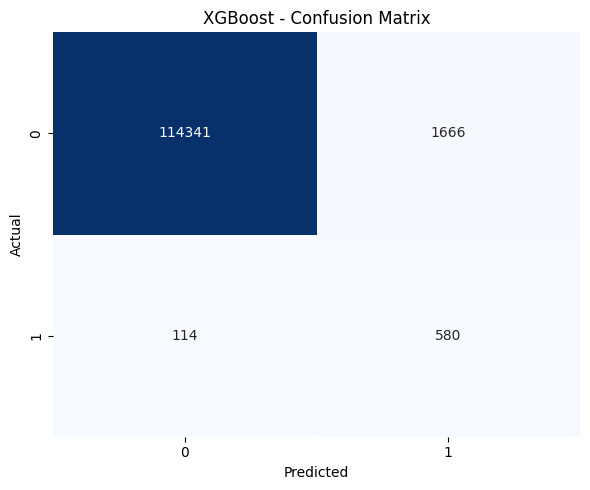

2025/10/10 07:19:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [41]:
y_pred_xgb = best_xgb_model.predict(X_test_scale)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("Accuracy:", accuracy_xgb)
print("F1 Score:", f1_xgb)
print(classification_report(y_test, y_pred_xgb))



cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()
plt.savefig("xgb_confusion_matrix.png")
plt.close()




with mlflow.start_run(run_name="XGBoost_Model"):

    mlflow.log_params(grid_xgb.best_params_)
    mlflow.log_metric("Accuracy", accuracy_xgb)
    mlflow.log_metric("F1_Score", f1_xgb)

    mlflow.sklearn.log_model(best_xgb_model, name="XGBoostModel")

    mlflow.log_artifact("xgb_confusion_matrix.png")

In [44]:
import mlflow
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

params_lgb = {
    "n_estimators": [100, 200],
    "num_leaves": [31, 63],
    "max_depth": [-1, 10, 20],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_samples": [10, 20],
    "scale_pos_weight": [1, 5, 10]    
}

lgbm = LGBMClassifier(
    objective="binary",
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    verbosity=-1
)


grid_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=params_lgb,
    n_iter=10,
    scoring="f1",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

grid_lgbm.fit(x_train_resample, y_train_resample)
best_lgbm_model = grid_lgbm.best_estimator_
print("Best Parameters for LightGBM:", grid_lgbm.best_params_)







  


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters for LightGBM: {'subsample': 0.8, 'scale_pos_weight': 1, 'num_leaves': 31, 'n_estimators': 100, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


D:\AI internship\ai_intern\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.3853351727920069
F1 Score: 0.0183918112649844
              precision    recall  f1-score   support

           0       1.00      0.38      0.55    116007
           1       0.01      0.97      0.02       694

    accuracy                           0.39    116701
   macro avg       0.50      0.68      0.29    116701
weighted avg       0.99      0.39      0.55    116701



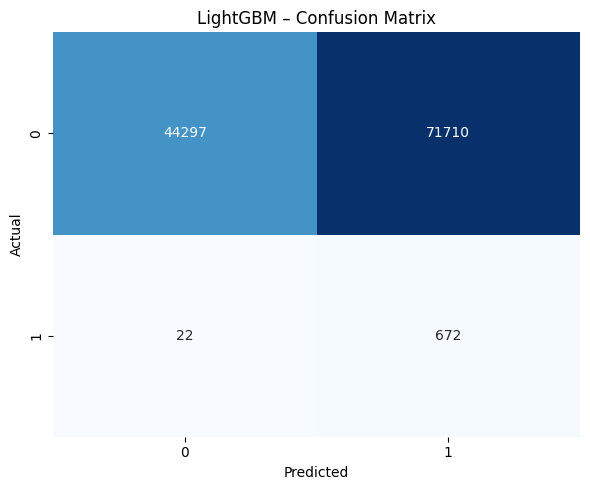

2025/10/10 07:34:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [45]:
y_pred_lgbm = best_lgbm_model.predict(X_test_scale)

accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)

print("Accuracy:", accuracy_lgbm)
print("F1 Score:", f1_lgbm)
print(classification_report(y_test, y_pred_lgbm))


cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM – Confusion Matrix")
plt.tight_layout()
plt.show()
plt.savefig("lgbm_confusion_matrix.png")
plt.close()



with mlflow.start_run(run_name="LightGBM_Model"):


    mlflow.log_params(grid_lgbm.best_params_)
    mlflow.log_metric("Accuracy", accuracy_lgbm)
    mlflow.log_metric("F1_Score", f1_lgbm)


    mlflow.sklearn.log_model(best_lgbm_model, name="LightGBM_Model")

 
    mlflow.log_artifact("lgbm_confusion_matrix.png")

import shap

X_test_df = pd.DataFrame(X_test_scale, columns=x_test.columns)

explainer = shap.TreeExplainer(best_model, feature_perturbation="tree_path_dependent")

shap_values = explainer.shap_values(X_test_df, check_additivity=False)


if isinstance(shap_values, list):
    shap_to_plot = shap_values[1] 
elif shap_values.ndim == 3:
    shap_to_plot = shap_values[..., 1]
else:
    shap_to_plot = shap_values


if shap_to_plot.shape[1] != X_test_df.shape[1]:
    shap_to_plot = shap_to_plot[:, :X_test_df.shape[1]]


with mlflow.start_run(run_name="RF_SHAP_Full_Test_Data"):

 
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("Accuracy", acc)
    mlflow.log_metric("F1_Score", f1)

    shap.summary_plot(shap_to_plot, X_test_df, feature_names=X_test_df.columns, show=False)
    plt.tight_layout()
    plt.savefig("shap_summary_full.png", bbox_inches="tight")
    mlflow.log_artifact("shap_summary_full.png")
    plt.close()
    
    shap.summary_plot(shap_to_plot, X_test_df, feature_names=X_test_df.columns, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig("shap_bar_full.png", bbox_inches="tight")
    mlflow.log_artifact("shap_bar_full.png")
    plt.close()

  
    mlflow.log_artifact("confusion_matrix.png")

 
    mlflow.sklearn.log_model(best_model, "RandomForestModel_FullTest")